# **Crisis de Salud, análisis de UPC anual entre 2002 y 2026**

Lo primero nace por entender que el sistema de salud en Colombia está organizado por el gobierno, las eps que contratan con hospitales e IPS, y los hospitales e IPS que son quienes prestan el servicio de salud. El esquema simplificado es el siguiente. El estado le gira a las EPS, las EPS administran ese dinero y le giran a hospitales e IPS, hospitales e IPS reciben el pago y prestan el servicio de salud. Hay dos regímenes, contributivo y subsidiado.

Entre el gobierno y las EPS hay varios flujos de dinero, pero los principales son dos: por concepto de "UPC", que cubre servicios estándar, que incluyen medicina general, cirugías, hospitalización, medicamentos del listado oficial, laboratorio clínico, promoción y prevención, y rehabilitación; por concepto de presupuestos máximos "PM", que cubre medicamentos de enfermedades huérfanas, medicamentos de alto costo o de condiciones específicas, alimentos nutricionales para propósito médico especial, servicios sociales complementarios y algunos procedimientos especiales. Hay una tercera bolsa que se llama recobros, pero históricamente se ha prestado para mucha corrupción, por lo que la bolsa de presupuestos máximos tomó su lugar en el 2020. Una idea de la proporción de los tamaños de cada bolsa es la siguiente. UPC corresponde al 95%, presupuestos máximos corresponde al 4,5% y recobros al 0,5% (Fuente: ANIF https://www.anif.com.co/wp-content/uploads/2023/11/4-marcela-brun.pdf).
Un ejemplo en valor monetario, es que el presupuesto máximo para la vigencia 2021 fue de 6,8 billones, y el giro por UPC del 2025 fue de 97,2 billones. Esto es solo para comparar el tamaño de las bolsas, no valores del mismo año.

El gobierno Petro, giró oportunamente la bolsa UPC, pero no cumplió de manera ni oportuna ni total con la bolsa PM (Fuente: ADRES https://www.adres.gov.co/lupa-al-giro). De manera pesimista se puede decir que cumplió con la bolsa más grande (UPC), e incumplió con la bolsa pequeña (PM). (*Es importante matizar que pesimista se refiere a que el gobierno no hubiera pagado ni un solo peso por la bolsa PM, pero los giros señalan que parte de esa bolsa sí se ha pagado, aunque de manera atrasada.*)

La crisis de salud está compuesta por muchos tipos de deuda y de desfinanciación. Por mencionar solo una, la deuda acumulada de las EPS con IPS se estima por \$ 25,7 billones a 2025 (Fuente: ACHC https://achc.org.co/actualidad/deuda-con-prestadores-de-servicios-de-salud-de-la-achc-llego-a-25-7-billones-de-pesos-en-2025/). Si el gobierno Petro cumplió con UPC, y le falta cumplir la bolsa PM por un valor de (caso pesimista) la totalidad de los 7 billones, por qué se tienen deudas del tamaño de los \$ 25,7 billones? La respuesta es muy sencilla. Si no es la bolsa de PM ni de recobros, porque son muy pequeñas, toca analizar la bolsa UPC, que es lo que se hará a continuación.

El análisis siguiente se resume en los siguientes pasos.
1. Obtener los valores de UPC nominal en pesos corrientes.

$$\text{UPC}_\text{nominal}(t)$$

2. Evaluar el aumento porcentual del UPC con respecto al año inmediato anterior.

$$ \text{Aumento UPC} = \frac{\text{UPC}_\text{nominal}(t)-\text{UPC}_\text{nominal}(t-1)}{\text{UPC}_\text{nominal}(t-1)} \text{x} 100$$

3. Restarle a este valor el IPC. Porque de nada sirve que se aumente el UPC un 30%, si la inflación es del 35%, porque se estaría girando incluso menos plata. Cuando se calcula el aumento porcentual del UPC - IPC, se está evaluando cuántos puntos porcentuales reales se aumentó en cada año.

$$ \text{Aumento real UPC} = \text{Aumento UPC} - \text{IPC}$$

4. Sumar cuántos puntos porcentuales aumentó cada gobierno en su mandato, para hacer una evaluación definitiva de los esfuerzos reales de cada gobierno por aumentar el UPC durante su mandato. Como el UPC se define en diciembre para el año posterior, no se incluye el valor del año en que se posesionaron, pero sí cuando dejaron el mandato. Por ejemplo, Uribe se posesionó en el 2002, pero él no decidió el UPC del 2002, este se decidió en diciembre del 2001 en el mandato anterior a Uribe. Entonces para evaluar la suma de Uribe, se tienen en cuenta los valores de Aumento real UPC para los años 2003, 2004, 2005 y 2006.

Se registran los datos de UPC nominal anual por régimen contributivo y subsidiado de https://www.asivamosensalud.org/indicadores/financiamiento/evolucion-de-la-upc-nominal-en-pesos-corrientes, y se complementa el valor del 2026 mediante resolución 2764 de 2025.

In [1]:
import pandas as pd

# Years from 2001 to 2026
years = list(range(2001, 2027))

UPC_years_C = [ # REGIMEN CONTRIBUTIVO
    289120, # 2001 Fuente: https://www.asivamosensalud.org/indicadores/financiamiento/evolucion-de-la-upc-nominal-en-pesos-corrientes
    304154, # 2002
    323316, # 2003
    344974, # 2004
    365673, # 2005
    386881, # 2006
    404215, # 2007
    430488, # 2008
    467078, # 2009
    485013, # 2010
    505627, # 2011
    547639, # 2012
    568944, # 2013
    593978, # 2014
    629975, # 2015
    689508, # 2016
    746046, # 2017
    804463, # 2018
    847180, # 2019
    892591, # 2020
    938826, # 2021
    989712, # 2022
    1289246.4, # 2023
    1444086, # 2024
    1521490, # 2025
    1658912.01  # 2026 Fuente: resolución 2764 de 2025
]

UPC_years_S = [ # REGIMEN Subsidiado
    155520, #2001
    168023, #2002
    179768, # 2003
    192344, # 2004
    203886, # 2005
    215712, # 2006
    227578, # 2007
    242370, # 2008
    267678, # 2009
    281836, # 2010
    302040, # 2011
    433667, # 2012
    508993, # 2013
    531389, # 2014
    563591, # 2015
    616849, # 2016
    667429, # 2017
    719690, # 2018
    787327, # 2019
    829526, # 2020
    872496, # 2021
    927723.6, # 2022
    1121396.4, # 2023
    1256076, # 2024
    1323403, # 2025
    1541706.27  # 2026 Fuente: resolución 2764 de 2025
]


# Create a DataFrame
df_UPC_manual = pd.DataFrame({
    'Year': years,
    'Total UPC C': UPC_years_C,
    'Total UPC S': UPC_years_S
})

display(df_UPC_manual.head())

,Year,Total UPC C,Total UPC S
0,2001,289120.0,155520.0
1,2002,304154.0,168023.0
2,2003,323316.0,179768.0
3,2004,344974.0,192344.0
4,2005,365673.0,203886.0


Se grafica la evolución temporal del UPC nominal

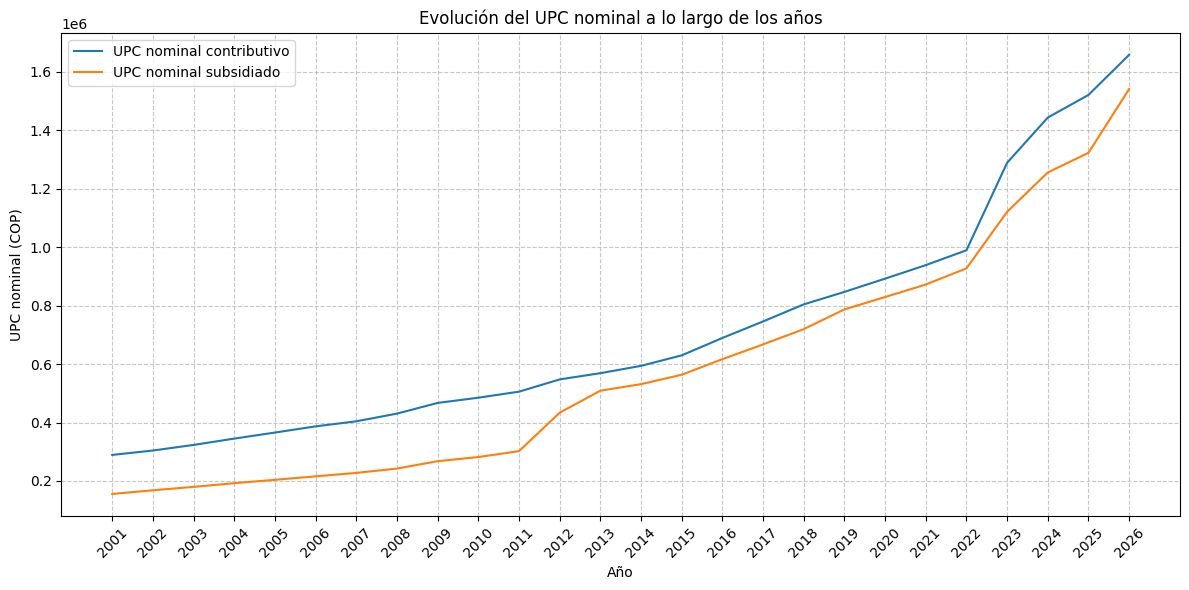

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Total UPC C', data=df_UPC_manual, label='UPC nominal contributivo')
sns.lineplot(x='Year', y='Total UPC S', data=df_UPC_manual, label='UPC nominal subsidiado')

plt.title('Evolución del UPC nominal a lo largo de los años')
plt.xlabel('Año')
plt.ylabel('UPC nominal (COP)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(df_UPC_manual['Year'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Se calculan los aumentos porcentuales con respecto al año anterior

In [3]:
# Calculate the percentage increase for 'Total UPC C'
df_UPC_manual['Increase_C (%)'] = df_UPC_manual['Total UPC C'].pct_change() * 100

# Calculate the percentage increase for 'Total UPC S'
df_UPC_manual['Increase_S (%)'] = df_UPC_manual['Total UPC S'].pct_change() * 100

# Display the DataFrame with the new columns, formatting the percentages
display(df_UPC_manual.style.format({'Increase_C (%)': '{:.2f}%', 'Increase_S (%)': '{:.2f}%'}))

,Year,Total UPC C,Total UPC S,Increase_C (%),Increase_S (%)
0,2001,289120.000000,155520.000000,nan%,nan%
1,2002,304154.000000,168023.000000,5.20%,8.04%
2,2003,323316.000000,179768.000000,6.30%,6.99%
3,2004,344974.000000,192344.000000,6.70%,7.00%
4,2005,365673.000000,203886.000000,6.00%,6.00%
5,2006,386881.000000,215712.000000,5.80%,5.80%
6,2007,404215.000000,227578.000000,4.48%,5.50%
7,2008,430488.000000,242370.000000,6.50%,6.50%
8,2009,467078.000000,267678.000000,8.50%,10.44%
9,2010,485013.000000,281836.000000,3.84%,5.29%


Se registran los valores de IPC acumulado por año. Del 2001 al 2025 se extrajo de https://www.consultorcontable.com/datos-hist%C3%B3ricos/ipc-historico/. Para el 2026, el último dato disponible por Banrep y Dane corresponde al primer trimestre (https://www.banrep.gov.co/es/publicaciones-investigaciones/informe-politica-monetaria/abril-2026# y https://www.dane.gov.co/index.php/estadisticas-por-tema/precios-y-costos/indice-de-precios-al-consumidor-ipc/ipc-informacion-tecnica). Aunque la tendencia del IPC durante gobierno Petro fue a bajar, en este momento está subiendo con una tasa muy moderada. Se usa un dato proyectivo de 6,4 para diciembre de 2026 dado por Banrep https://www.banrep.gov.co/es/publicaciones-investigaciones/informe-politica-monetaria/abril-2026

In [4]:
IPC_years = [ # IPC colombia
    7.65, #2001 Fuente: https://www.consultorcontable.com/datos-hist%C3%B3ricos/ipc-historico/
    6.99, #2002
    6.49, # 2003
    5.50, # 2004
    4.85, # 2005
    4.48, # 2006
    5.69, # 2007
    7.67, # 2008
    2, # 2009
    3.17, # 2010
    3.73, # 2011
    2.44, # 2012
    1.94, # 2013
    3.66, # 2014
    6.77, # 2015
    5.75, # 2016
    4.09, # 2017
    3.18, # 2018
    3.80, # 2019
    1.61, # 2020
    5.62, # 2021
    13.12, # 2022 Una explicación interesante del aumento tan grande de la infración está en https://www.banrep.gov.co/es/blog/determinantes-brote-inflacionario-pospandemia
    9.28, # 2023
    5.20, # 2024
    5.10, # 2025
    6.4 # 2026 primer trimestre https://www.banrep.gov.co/es/publicaciones-investigaciones/informe-politica-monetaria/abril-2026
              # y https://www.dane.gov.co/index.php/estadisticas-por-tema/precios-y-costos/indice-de-precios-al-consumidor-ipc/ipc-informacion-tecnica. Dato proyectado
              # https://www.banrep.gov.co/es/publicaciones-investigaciones/informe-politica-monetaria/abril-2026
]

Se juntan los datos en un solo dataframe

In [5]:
# Add the IPC_years list as a new column 'IPC' to the DataFrame
df_UPC_manual['IPC (%)'] = IPC_years

# Display the updated DataFrame
display(df_UPC_manual.style.format({'Increase_C (%)': '{:.2f}%', 'Increase_S (%)': '{:.2f}%'}))

,Year,Total UPC C,Total UPC S,Increase_C (%),Increase_S (%),IPC (%)
0,2001,289120.000000,155520.000000,nan%,nan%,7.650000
1,2002,304154.000000,168023.000000,5.20%,8.04%,6.990000
2,2003,323316.000000,179768.000000,6.30%,6.99%,6.490000
3,2004,344974.000000,192344.000000,6.70%,7.00%,5.500000
4,2005,365673.000000,203886.000000,6.00%,6.00%,4.850000
5,2006,386881.000000,215712.000000,5.80%,5.80%,4.480000
6,2007,404215.000000,227578.000000,4.48%,5.50%,5.690000
7,2008,430488.000000,242370.000000,6.50%,6.50%,7.670000
8,2009,467078.000000,267678.000000,8.50%,10.44%,2.000000
9,2010,485013.000000,281836.000000,3.84%,5.29%,3.170000


Se calcula el aumento real del UPC por régimen contributivo y subsidado

In [6]:
# Calculate delta_C: Increase_C (%) - IPC (%)
df_UPC_manual['delta_C'] = df_UPC_manual['Increase_C (%)'] - df_UPC_manual['IPC (%)']

# Calculate delta_S: Increase_S (%) - IPC (%)
df_UPC_manual['delta_S'] = df_UPC_manual['Increase_S (%)'] - df_UPC_manual['IPC (%)']

# Display the DataFrame with the new columns, formatting the percentages
display(df_UPC_manual.style.format({
    'Increase_C (%)': '{:.2f}%',
    'Increase_S (%)': '{:.2f}%',
    'IPC (%)': '{:.2f}%',
    'delta_C': '{:.2f}%',
    'delta_S': '{:.2f}%'
}))

,Year,Total UPC C,Total UPC S,Increase_C (%),Increase_S (%),IPC (%),delta_C,delta_S
0,2001,289120.000000,155520.000000,nan%,nan%,7.65%,nan%,nan%
1,2002,304154.000000,168023.000000,5.20%,8.04%,6.99%,-1.79%,1.05%
2,2003,323316.000000,179768.000000,6.30%,6.99%,6.49%,-0.19%,0.50%
3,2004,344974.000000,192344.000000,6.70%,7.00%,5.50%,1.20%,1.50%
4,2005,365673.000000,203886.000000,6.00%,6.00%,4.85%,1.15%,1.15%
5,2006,386881.000000,215712.000000,5.80%,5.80%,4.48%,1.32%,1.32%
6,2007,404215.000000,227578.000000,4.48%,5.50%,5.69%,-1.21%,-0.19%
7,2008,430488.000000,242370.000000,6.50%,6.50%,7.67%,-1.17%,-1.17%
8,2009,467078.000000,267678.000000,8.50%,10.44%,2.00%,6.50%,8.44%
9,2010,485013.000000,281836.000000,3.84%,5.29%,3.17%,0.67%,2.12%


Se grafican los resultados

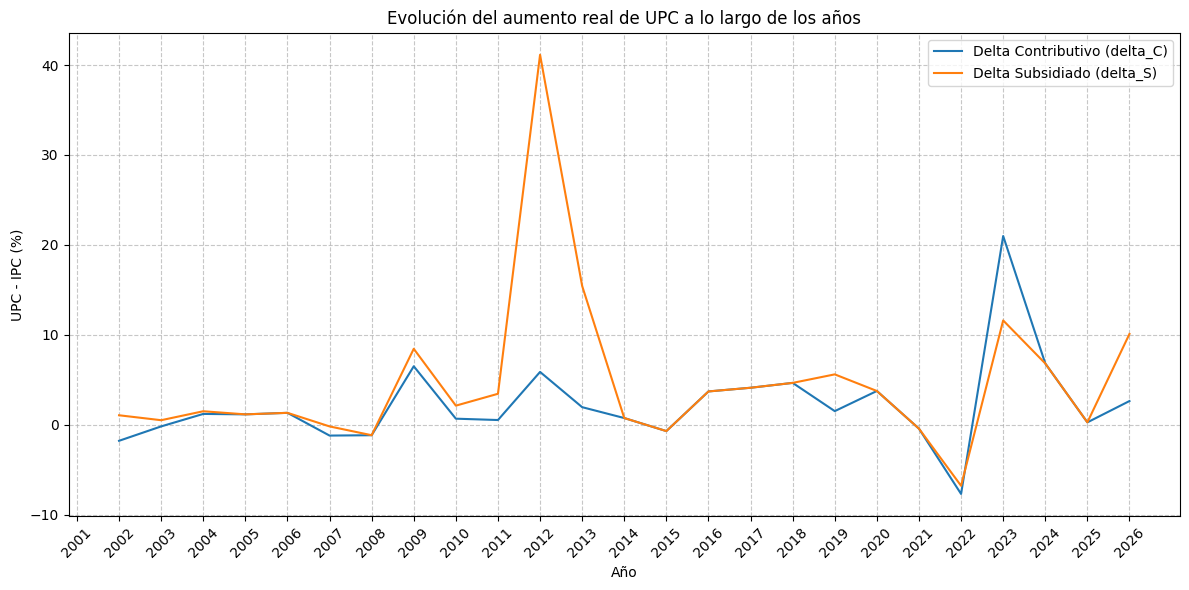

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='delta_C', data=df_UPC_manual, label='Delta Contributivo (delta_C)')
sns.lineplot(x='Year', y='delta_S', data=df_UPC_manual, label='Delta Subsidiado (delta_S)')

plt.title('Evolución del aumento real de UPC a lo largo de los años')
plt.xlabel('Año')
plt.ylabel('UPC - IPC (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(df_UPC_manual['Year'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Se calculan los puntos porcentuales totales por mandato, que surgen de sumar los datos desde el año siguiente al que se posesionaron, hasta el año en que dejaron el mandato, porque el UPC se define en diciembre.

In [8]:
def assign_mandate(year):
    if 2003 <= year <= 2006:
        return 'Mandato Uribe 1'
    elif 2007 <= year <= 2010:
        return 'Mandato Uribe 2'
    elif 2011 <= year <= 2014:
        return 'Mandato Santos 1'
    elif 2015 <= year <= 2018:
        return 'Mandato Santos 2'
    elif 2019 <= year <= 2022:
        return 'Mandato Duque'
    elif 2023 <= year <= 2026:
        return 'Mandato Petro'
    return 'Otros'

df_UPC_manual['Mandato'] = df_UPC_manual['Year'].apply(assign_mandate)

# Filter out 'Otros' if any years fall outside the defined mandates
df_mandates = df_UPC_manual[df_UPC_manual['Mandato'] != 'Otros']

# Aggregate delta_C and delta_S by mandate
aggregated_deltas = df_mandates.groupby('Mandato')[['delta_C', 'delta_S']].sum().reset_index()

from pandas.api.types import CategoricalDtype

mandate_order = [
    'Mandato Uribe 1',
    'Mandato Uribe 2',
    'Mandato Santos 1',
    'Mandato Santos 2',
    'Mandato Duque',
    'Mandato Petro'
]

# Convert 'Mandato' column to a categorical type with the specified order
cat_type = CategoricalDtype(categories=mandate_order, ordered=True)
aggregated_deltas['Mandato'] = aggregated_deltas['Mandato'].astype(cat_type)

# Sort the DataFrame by the ordered 'Mandato' column
sorted_aggregated_deltas = aggregated_deltas.sort_values('Mandato').reset_index(drop=True)

display(sorted_aggregated_deltas.style.format({'delta_C': '{:.2f}%', 'delta_S': '{:.2f}%'}))

,Mandato,delta_C,delta_S
0,Mandato Uribe 1,3.48%,4.47%
1,Mandato Uribe 2,4.79%,9.20%
2,Mandato Santos 1,9.08%,60.75%
3,Mandato Santos 2,11.75%,11.75%
4,Mandato Duque,-2.88%,2.12%
5,Mandato Petro,30.69%,28.76%


### Diagramas de barras para `Aumento real UPC_C neto` y `Aumento real UPC_S neto` por Mandato

Se grafica resultados netos por mandato en régimen contributivo

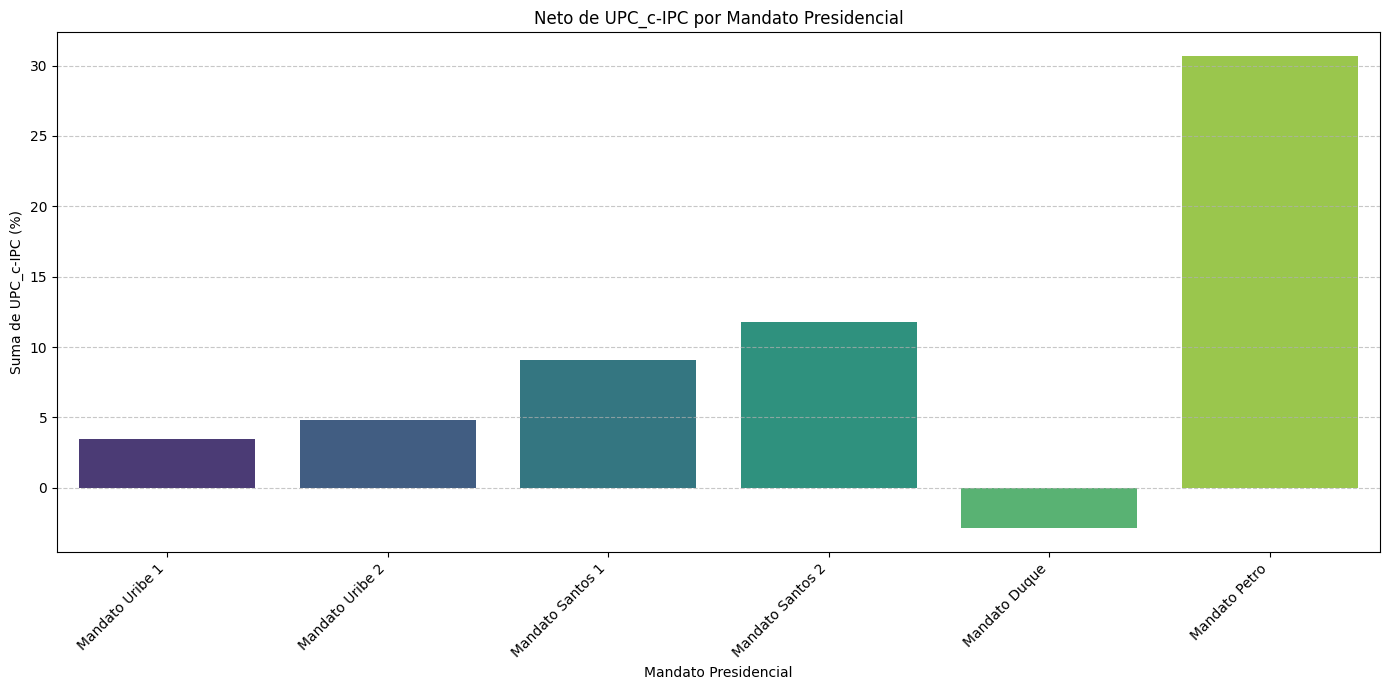

In [9]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Mandato', y='delta_C', data=aggregated_deltas, palette='viridis', hue='Mandato', legend=False)
plt.title('Neto de UPC_c-IPC por Mandato Presidencial')
plt.xlabel('Mandato Presidencial')
plt.ylabel('Suma de UPC_c-IPC (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Y en régimen subsidiado

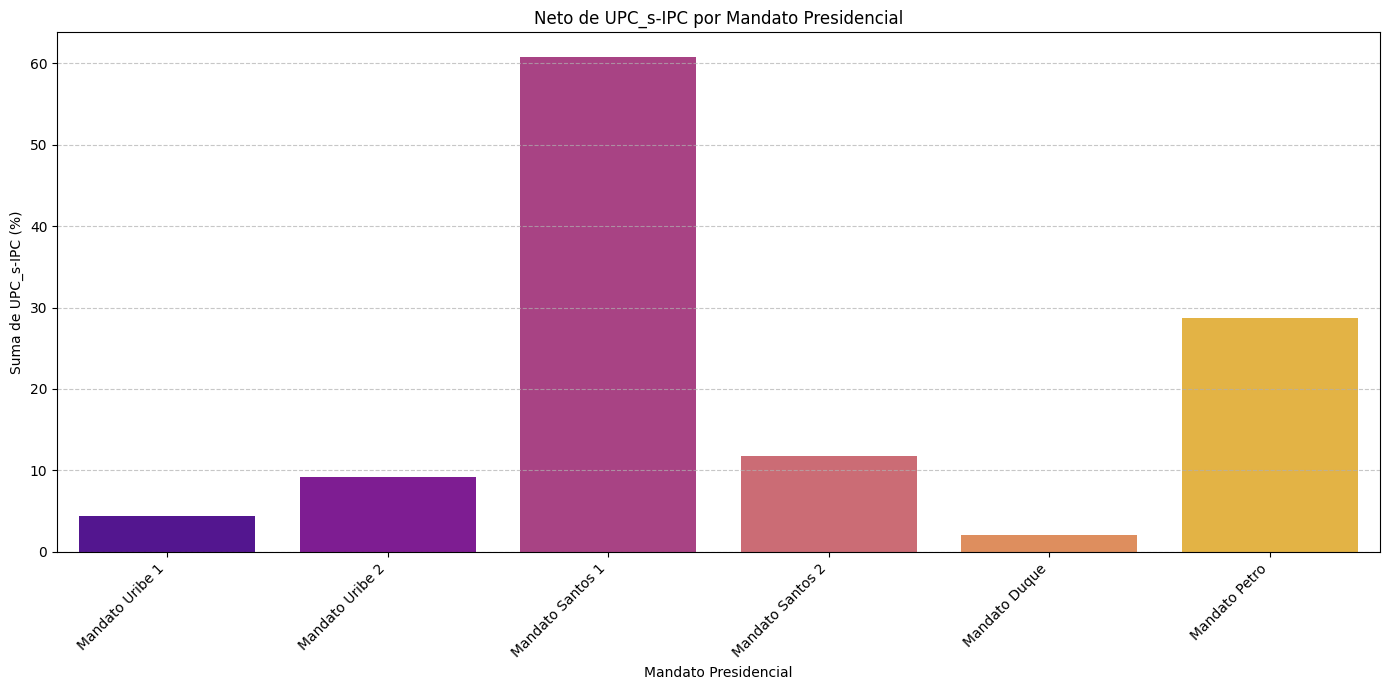

In [10]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Mandato', y='delta_S', data=aggregated_deltas, palette='plasma', hue='Mandato', legend=False)
plt.title('Neto de UPC_s-IPC por Mandato Presidencial')
plt.xlabel('Mandato Presidencial')
plt.ylabel('Suma de UPC_s-IPC (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Aquí se ven varias cosas.
1. Ninguno de los mandatos de Uribe ni el de Duque aumentó significativamente el UPC. De hecho, el neto de gobierno Duque aumentó el UPC por debajo del IPC (O sea, no lo aumentó realmente).
2. En subsidiado, gobierno Santos fue el que más aumentó el UPC subsidiado (esto es debido a la Ley 1438 que obligaba a igualar UPC subsidiado al contributivo, no porque fuera el más generoso), y le sigue el gobierno Petro.
3. En contributivo, la gráfica es directa, el gobierno Petro es el que más ha aumentado el UPC contributivo realmente.

# **Pero si el gobierno Petro es el que más ha aumentado el UPC, entonces de dónde viene la crisis que vivimos hoy en salud?**

El UPC es la Unidad de Pago por Capitación, y corresponde a lo que el Gobierno paga a la EPS por cada afiliado para garantizar su atención en salud. Este valor no lo define el sector privado, ni grupos neutrales. Lo define el mismo Ministerio de Salud de cada gobierno.

La Corte Constitucional en su sentencia T-760 del 2008 (https://www.corteconstitucional.gov.co/relatoria/2008/t-760-08.htm), declaró de forma definitiva que la salud es un derecho fundamental autónomo y no un simple servicio supeditado a otros derechos, obligando al Estado y a las EPS a garantizar una atención integral y oportuna. Desde esta sentencia, la corte es capaz de dar opiniones cuando este derecho fundamental no se está garantizando. Una de las aristas que más discuten en sus autos (los seguimientos que se hacen al cumplimiento de esta sentencia), es que el UPC **NUNCA** ha sido suficiente para garantizar el derecho a la salud. La proyección del UPC nunca ha correspondido a lo que en realidad cuesta prestar el servicio de salud. La diferencia entre el UPC efectivo (el que se necesita para garantizar el derecho) y el que definen los ministerios de salud es conocido como el deficit. Sin embargo, estimar el deficit no es una tarea trivial y no hay un consenso sobre cómo hacerlo. El Auto 007 de 2025 de la corte, uno de los seguimientos que la corte ha hecho a la sentencia T-760 (https://www.corteconstitucional.gov.co/relatoria/autos/2025/a007-25.htm), reporta estimaciones de varios actores, aunque todos del sector privado. ACEMI reporta que entre 2011 y 2023 hubo un deficit de 15,8 billones, ANIF que entre 2022 y 2023 el deficit está en el orden de 4 billones, ANDI menciona 4,8 billones entre 2021 y 2023 y de 4,4 billones solo en el 2024, Pacientes Colombia por su lado dice que entre 2021 y 2023 hubo 5 billones en perdidas de las EPS y proyectó 4,2 billones en perdidas para 2024. Es decir, en acumulado ACEMI dice que se deben 15,8 billones a 2023, ANDI 9,2 billones a 2024, Pacientes Colombia 9,2 billones. Solo por UPC.

Fuentes más neutrales, como el Grupo de Economía de Salud (GES) de la UdeA, mencionan que el desfase del UPC en 2022 fue de 7,2 % y de 4,9 % en 2023. Alrededor de \$ 7,1 billones para estos dos años (https://gesudea.co/wp-content/uploads/2024/09/Observatorio-de-la-Seguridad-Social-No-45.pdf). Pero concuerda en que históricamente ha habido deficit de UPC.

Una cara que complementa la insuficiencia del UPC es la siniestralidad, que es el porcentaje de la UPC que la EPS efectivamente gasta en prestar servicios de salud. La ley 100 proyectaba que la siniestralidad debe estar por el orden del 90%, para que el 10% restante se vaya a la operación de las EPS. La siniestralidad del régimen contributivo fue 102,5% en 2022 (Auto 007 T-760), lo que significa que las EPS estaban gastando más de lo que recibian. Sin embargo, **no hay conclusiones definitivas sobre la medida exacta en que esto es responsabilidad de que el UPC es insuficiente o a que las EPS no gestionan bien los recursos que recibieron.**

El diagnóstico es que, tanto para hacer mejores proyecciones de UPC, como para saber si las EPS gestionaron bien su dinero, la trazabilidad del dinero que reciben las EPS es un eje central de la discusión. También, que esta es una discusión técnica que debe cuestionar los modelos y su financiamiento. Desde quién es el que decide el valor de UPC, hasta qué rol realmente toman las EPS en el sistema de salud colombiano. Porque de todas formas ellas no prestan los servicios de salud, quienes prestan el servicio de salud son los hospitales y las IPS. Es una problemática que va más allá de inyectar dinero ciegamente.

Hay cuatro conclusiones grandes.
1. La crisis de salud que vivimos hoy en Colombia, es una bola de nieve que llevamos arrastrando desde la creación de la Ley 100 en 1993.
2. Ningún gobierno ha podido solucionar la crisis de salud. Eso incluye el gobierno Petro.
3. Sin embargo, en términos de bolsa UPC contributiva (que es la más grande), el gobierno Petro es el que más se ha esforzado en detener o ralentizar la crisis en toda la serie analizada. En UPC subsidiada, el gobierno Santos 1 registra el mayor aumento real, aunque esto se explica por la obligación legal de igualar los regímenes mediante la Ley 1438 de 2011, no por una decisión discrecional de política. Aun así, en subsidiada el gobierno Petro también sigue aportando mucho más que los gobiernos de Uribe y Duque.
4. El gobierno que menos ha aportado a la bolsa UPC (la más grande) fue el gobierno Duque. En contributivo, su aumento neto estuvo incluso por debajo de la misma inflación. Y en subsidiado, aumentó 2 puntos porcentuales en todo su gobierno.

## **Nota Aclaratoria**

* La sentencia T-760 es del 2008. Antes del 2008, no había nadie que determinara si el derecho a la salud se estaba garantizando o no. Sin embargo, que la corte tuviera que sacar esta sentencia para empezar a vigilar, implica que existieron los antecedentes suficientes. La salud no estaba bien durante el gobierno Uribe, y la creación de esta sentencia es una evidencia de ello.